# Próxima sesión — agenda de trabajo

Seis frentes quedaron abiertos tras la sesión del 14 de julio, en el orden de
prioridad acordado; la sección 7 se añadió después y mide cuánto le queda al
miope frente a un lookahead de un paso (rollout) en instancias como las del
paper (N=50). Nada está escrito a mano: cada valor se computa en su celda y,
donde hay verdad de referencia, un `assert` lo audita.

El cuaderno distingue tres regímenes: el esquema estático (los pools se fijan
de antemano), el dinámico binario (adaptativo, pero la prueba sólo dice 0 vs.
≥1) y el dinámico aumentado (adaptativo, con conteo exacto). La tesis del
proyecto es que la ganancia vive en el aumentado.

In [1]:
import sys
from pathlib import Path

# Funciona tanto al ejecutar desde la raíz del repositorio como desde notebooks/.
ROOT = next((d for d in (Path.cwd(), *Path.cwd().parents)
             if (d / 'augmented').is_dir()), None)
if ROOT is None:
    raise RuntimeError('No se encontró la raíz que contiene augmented/')
sys.path.insert(0, str(ROOT))

import math, time, random
import numpy as np
import matplotlib.pyplot as plt

AZUL, GRIS, AMBAR, TINTA = '#2563eb', '#6b7280', '#d97706', '#374151'
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True,
                     'grid.alpha': 0.25, 'grid.linewidth': 0.5, 'font.size': 10})

from augmented.core import mask_from_indices, indices_from_mask
from augmented.solver import solve_optimal_dapts
from augmented.greedy import (greedy_myopic_expected_utility,
                              _myopic_best_pool)
from augmented.bayesian import gibbs_update, bayesian_update_by_counting
from augmented.certificates import u_pi_exact, u_pen_exact
from augmented.state_reward_greedy import (greedy_myopic_beta_expected_utility,
                                            greedy_myopic_beta_simulate)
print('setup listo')

setup listo


## 1. Separación en el régimen de activación alta

Sea $Z_i=1$ el estado activo y $q=\Pr(Z_i=0)$ la probabilidad de estado libre.
Con $q$ pequeña, una consulta binaria grupal casi siempre devuelve “hay al
menos un activo”; el conteo exacto conserva mucha más resolución. Conviene
separar dos afirmaciones: (i) una estrategia aumentada explícita supera al
óptimo estático binario, y (ii) el óptimo dinámico binario coincide con el
estático. Esta sección demuestra (i) y sólo aporta evidencia finita para (ii),
que sigue siendo una obligación de prueba.

Para $q\le 1/2$, el óptimo estático binario homogéneo usa consultas
individuales y vale $Bq\,u$. Una estrategia dinámica aumentada puede explorar
$k_G=(B-\log_2G)G$ agentes y localizar uno en estado libre, si existe, así que
obtiene al menos $[1-(1-q)^{k_G}]u$. En el ejemplo ancla ($q=0.1$, $G=16$,
$B=6$) esta cota es aproximadamente 61% mayor que $Bq\,u$; la igualdad (ii) no
se deduce de esta cuenta.

In [2]:
# --- las dos utilidades del ejemplo, en forma cerrada ---
def util_estatico_binario(B, q):
    '''Óptimo estático homogéneo para q<=1/2 y al menos B agentes: B*q.'''
    if not (0 <= q <= 0.5):
        raise ValueError('esta fórmula de óptimo estático requiere 0 <= q <= 1/2')
    return B * q

def cota_inferior_aumentada(B, G, q):
    '''Cota inferior de una estrategia dinámica aumentada: 1-(1-q)^(kG),
    con kG=(B-log2 G)*G personas cubiertas. G debe ser potencia de 2.'''
    logG = math.log2(G)
    if abs(logG - round(logG)) > 1e-9:
        raise ValueError('G debe ser potencia de 2')
    k = B - round(logG)
    if k < 1:
        return None, None
    kG = k * G
    return 1.0 - (1.0 - q) ** kG, kG

q, G, B = 0.1, 16, 6
est = util_estatico_binario(B, q)
din, kG = cota_inferior_aumentada(B, G, q)
print(f'ancla q={q}  G={G}  B={B}   ->  cubre kG={kG} personas (k={B-round(math.log2(G))})')
print(f'  estático        U/u = B*q         = {est:.3f}')
print(f'  cota aumentada  L/u = 1-(1-q)^kG  = {din:.3f}')
print(f'  ventaja del aumentado: {din-est:+.3f}u  ({100*(din/est-1):+.0f}%)')

ancla q=0.1  G=16  B=6   ->  cubre kG=32 personas (k=2)
  estático        U/u = B*q         = 0.600
  cota aumentada  L/u = 1-(1-q)^kG  = 0.966
  ventaja del aumentado: +0.366u  (+61%)


In [3]:
# La constante de cobertura: kG = (B - log2 G)*G = Theta(B*G), no ~B.
# Por Bernoulli 1-(1-q)^m <= m*q, así que con cobertura ~B el aumentado NO
# ganaría (quedaría bajo B*q); es el factor G el que abre la brecha.
con_B  = 1 - (1 - q) ** B     # cobertura ~B (la aproximación floja)
con_kG = 1 - (1 - q) ** kG    # cobertura real Theta(B*G)
assert con_B <= B * q + 1e-12, 'Bernoulli: con cobertura ~B no se supera al estático'
assert con_kG > est, 'con la cobertura real kG el aumentado sí separa'
print(f'cobertura ~B  -> 1-(1-q)^B  = {con_B:.3f}   (<= B*q = {est:.3f}: no separa)')
print(f'cobertura kG  -> 1-(1-q)^kG = {con_kG:.3f}   (> B*q: separa)')

cobertura ~B  -> 1-(1-q)^B  = 0.469   (<= B*q = 0.600: no separa)
cobertura kG  -> 1-(1-q)^kG = 0.966   (> B*q: separa)


In [4]:
# Auditoría de la ruta de concentración sugerida en la sesión.
# En el ancla, el evento "hay >=2 agentes libres" NO es raro: esa ruta no
# demuestra la igualdad dinámico-binario = estático con estos parámetros.
def prob_ge2_libres(m, q):
    p0 = (1 - q) ** m
    p1 = m * q * (1 - q) ** (m - 1)
    return 1.0 - p0 - p1
colas = [prob_ge2_libres(kG, qq) for qq in [0.05, 0.1, 0.15, 0.2]]
assert colas[1] > 0.8, 'la auditoría debe exhibir que la cola del ancla no es pequeña'
for qq, cola in zip([0.05, 0.1, 0.15, 0.2], colas):
    print(f'q={qq}: P(>=2 libres entre {kG}) = {cola:.3f}')
print('Conclusión: la concentración propuesta no justifica el ancla q=0.1.')

q=0.05: P(>=2 libres entre 32) = 0.480
q=0.1: P(>=2 libres entre 32) = 0.844
q=0.15: P(>=2 libres entre 32) = 0.963
q=0.2: P(>=2 libres entre 32) = 0.993
Conclusión: la concentración propuesta no justifica el ancla q=0.1.


In [5]:
# Familia asintótica que sí prueba una brecha relativa no acotada.
# Tome B=2 log2(G), kG=G log2(G) y q=1/kG. Entonces la cota aumentada
# tiende a 1-e^-1, mientras el estático vale 2/G: la razón es Theta(G).
familia = []
for Gf in [8, 16, 32, 64, 128]:
    Bf = 2 * round(math.log2(Gf))
    kGf = (Bf - round(math.log2(Gf))) * Gf
    qf = 1.0 / kGf
    sf = util_estatico_binario(Bf, qf)
    lf, _ = cota_inferior_aumentada(Bf, Gf, qf)
    familia.append((Gf, Bf, qf, sf, lf, lf / sf))
print('G    B       q          estático   cota-aum   razón')
for Gf, Bf, qf, sf, lf, ratio in familia:
    print(f'{Gf:<4} {Bf:<3} {qf:>9.6f}   {sf:>8.4f}   {lf:>8.4f}   {ratio:>6.2f}')
assert familia[-1][-1] > familia[0][-1] * 10, 'la razón debe crecer linealmente con G'

G    B       q          estático   cota-aum   razón
8    6    0.041667     0.2500     0.6399     2.56
16   8    0.015625     0.1250     0.6350     5.08
32   10   0.006250     0.0625     0.6333    10.13
64   12   0.002604     0.0312     0.6326    20.24
128  14   0.001116     0.0156     0.6323    40.47


In [6]:
# Evidencia finita con DP exacto; NO sustituye la prueba general.
# cap=1 binariza (0 vs >=1); cap=None deja el conteo.
n_d, G_d, B_d = 5, 4, 4
qs = [0.10, 0.15, 0.20, 0.25, 0.30]
u_est, u_bin, u_cont = [], [], []
for qq in qs:
    p = [1.0 - qq] * n_d; u = [1.0] * n_d
    s = B_d * qq
    vb = solve_optimal_dapts(p, u, B_d, G_d, cap=1)[0]     # dinámico BINARIO
    vc = solve_optimal_dapts(p, u, B_d, G_d, cap=None)[0]  # dinámico CONTEO
    assert abs(vb - s) < 1e-9, f'din-binario != estático en q={qq}'
    assert vc >= vb - 1e-9, f'el conteo quedó bajo el binario en q={qq}'
    u_est.append(s); u_bin.append(vb); u_cont.append(vc)
print('q     estático  din-binario  din-conteo')
for qq, s, b, c in zip(qs, u_est, u_bin, u_cont):
    print(f'{qq:<5} {s:>8.3f} {b:>12.3f} {c:>11.3f}')

q     estático  din-binario  din-conteo
0.1      0.400        0.400       0.490
0.15     0.600        0.600       0.728
0.2      0.800        0.800       0.963
0.25     1.000        1.000       1.194
0.3      1.200        1.200       1.424


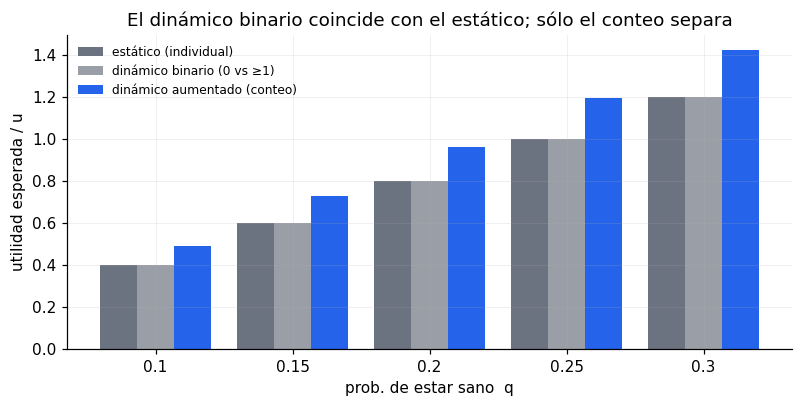

In [7]:
x = np.arange(len(qs)); w = 0.27
fig, ax = plt.subplots(figsize=(7.4, 3.8))
ax.bar(x - w, u_est, w, color=GRIS, label='estático (individual)')
ax.bar(x, u_bin, w, color=TINTA, alpha=0.5, label='dinámico binario (0 vs ≥1)')
ax.bar(x + w, u_cont, w, color=AZUL, label='dinámico aumentado (conteo)')
ax.set_xticks(x); ax.set_xticklabels([str(q) for q in qs])
ax.set_xlabel('prob. de estar sano  q'); ax.set_ylabel('utilidad esperada / u')
ax.set_title('El dinámico binario coincide con el estático; sólo el conteo separa')
ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

En el barrido pequeño el dinámico binario coincide con el estático y el
conteo lo supera; es evidencia computacional, no una prueba asintótica. La
brecha aumentada ya tiene familia rigurosa: ~61% en el ancla y razón
$\Theta(G)$ en la familia $B=2\log_2G$, $q=1/(G\log_2G)$. Contando con cuidado
la cobertura es $k_G=(B-\log_2 G)\,G$, no $\Theta(B)$; lo pendiente es una
prueba independiente de que el óptimo dinámico binario vale $Bq\,u$, y la cola
del ancla no sirve para ese paso.

## 2. Caso base laminar: una cadena de pools anidados

El ejemplo de separación —grupos de 16 dentro de 32, con el binary search
anidando grupos menores— forma una cadena laminar. Los conteos anidados se
restan: si un pool de 6 tiene conteo 2 y su hijo de 3 tiene conteo 1, el
anillo “6 menos 3” tiene exactamente 1 activo, y cada anillo queda como un
problema independiente de “exactamente $c$ activos entre $m$”. Para una cadena
estrictamente anidada el posterior exacto factoriza por anillos y se computa
en $O(m^3)$ por anillo, sin enumerar los $2^n$ perfiles; coincide con fuerza
bruta donde ésta corre y escala a cientos de agentes. Es el caso base de
inferencia: falta la familia laminar con ramificaciones y la optimización
dinámica sobre políticas.

In [8]:
# Inferencia laminar exacta por descomposición en anillos.
def _pois_binom(probs):
    dp = [1.0]
    for pr in probs:
        ndp = [0.0] * (len(dp) + 1)
        for k, v in enumerate(dp):
            ndp[k] += v * (1 - pr); ndp[k + 1] += v * pr
        dp = ndp
    return dp

def laminar_marginals(p, chain, n):
    '''chain: lista no vacía de (miembros, conteo) estrictamente anidada.
    Devuelve P(Z_i=1 | conteos) exacta, factorizando por anillos.'''
    if len(p) != n or not chain:
        raise ValueError('p debe tener longitud n y chain no puede estar vacía')
    if any(pr < 0 or pr > 1 for pr in p):
        raise ValueError('las probabilidades deben estar en [0,1]')
    ch = sorted(chain, key=lambda t: -len(t[0]))
    sets = [set(m) for m, _ in ch]; counts = [c for _, c in ch]
    if any(not s or any(i < 0 or i >= n for i in s) for s in sets):
        raise ValueError('cada pool debe ser no vacío y usar índices válidos')
    if any(not sets[j + 1] < sets[j] for j in range(len(sets) - 1)):
        raise ValueError('esta rutina sólo acepta una cadena estrictamente anidada')
    if any(c < 0 or c > len(s) for s, c in zip(sets, counts)):
        raise ValueError('cada conteo debe estar entre 0 y el tamaño de su pool')
    marg = list(p)
    for j in range(len(ch)):
        inner = sets[j + 1] if j + 1 < len(ch) else set()
        anillo = list(sets[j] - inner)                              # capa j sin su hijo
        c = counts[j] - (counts[j + 1] if j + 1 < len(ch) else 0)   # conteo del anillo
        if c < 0 or c > len(anillo):
            raise ValueError('conteos incompatibles entre un pool y su hijo')
        probs = [p[i] for i in anillo]
        g = _pois_binom(probs); denom = g[c]
        if denom <= 0:
            raise ValueError('el historial factorizado tiene probabilidad cero')
        for idx, i in enumerate(anillo):
            otros = probs[:idx] + probs[idx + 1:]
            go = _pois_binom(otros)
            num = p[i] * (go[c - 1] if 0 <= c - 1 < len(go) else 0.0)
            marg[i] = num / denom
    return marg
print('laminar_marginals listo')

laminar_marginals listo


In [9]:
# (a) verificación contra fuerza bruta en n chico
random.seed(4); n = 6
p = [round(random.uniform(0.2, 0.8), 2) for _ in range(n)]
chain = [(list(range(6)), 3), (list(range(3)), 2)]   # A={0..5} r=3  >  B={0..2} r=2
hist = tuple((mask_from_indices(m), c) for m, c in chain)
exact = bayesian_update_by_counting(p, hist, n)
lam = laminar_marginals(p, chain, n)
err = max(abs(exact[i] - lam[i]) for i in range(n))
assert err < 1e-9, f'laminar no coincide con fuerza bruta (err={err})'
print(f'n={n}: max |laminar - fuerza bruta| = {err:.2e}  (coinciden)')
print('marginales:', [round(v, 3) for v in lam])

n=6: max |laminar - fuerza bruta| = 2.22e-16  (coinciden)
marginales: [0.68, 0.53, 0.79, 0.271, 0.209, 0.52]


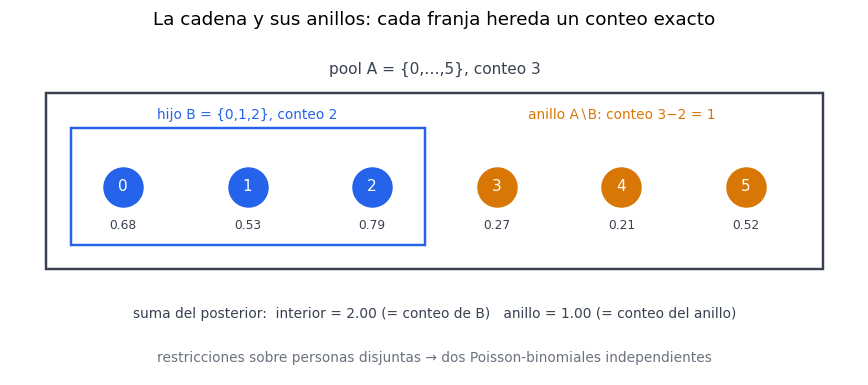

In [10]:
# el dibujo de la cadena: dos pools anidados y el anillo que queda al restar
(mA, cA), (mB, cB) = chain
interior = sorted(mB); anillo = sorted(set(mA) - set(mB)); c_anillo = cA - cB

# la imagen es fiel a la matemática: la suma del posterior de cada franja es su conteo
s_int = sum(lam[i] for i in interior); s_ani = sum(lam[i] for i in anillo)
assert abs(s_int - cB) < 1e-9 and abs(s_ani - c_anillo) < 1e-9, \
    'la suma de marginales de cada franja debe dar su conteo exacto'

from matplotlib.patches import Rectangle
fig, ax = plt.subplots(figsize=(8.0, 3.6))
ax.add_patch(Rectangle((-0.62, 0.45), 6.24, 0.75, fill=False, color=TINTA, lw=1.6))
ax.add_patch(Rectangle((-0.42, 0.55), 2.84, 0.50, fill=False, color=AZUL, lw=1.6))
for i in range(n):
    ax.scatter(i, 0.8, s=650, color=AZUL if i in mB else AMBAR, zorder=3)
    ax.text(i, 0.8, str(i), ha='center', va='center', color='white', zorder=4)
    ax.text(i, 0.62, f'{lam[i]:.2f}', ha='center', fontsize=8, color=TINTA)
ax.text(2.5, 1.28, f'pool A = {{0,…,5}}, conteo {cA}', ha='center', color=TINTA)
ax.text(1.0, 1.09, f'hijo B = {{0,1,2}}, conteo {cB}', ha='center', color=AZUL, fontsize=9)
ax.text(4.0, 1.09, f'anillo A∖B: conteo {cA}−{cB} = {c_anillo}', ha='center',
        color=AMBAR, fontsize=9)
ax.text(2.5, 0.24, f'suma del posterior:  interior = {s_int:.2f} (= conteo de B)   '
        f'anillo = {s_ani:.2f} (= conteo del anillo)', ha='center', fontsize=9, color=TINTA)
ax.text(2.5, 0.05, 'restricciones sobre personas disjuntas → dos Poisson-binomiales'
        ' independientes', ha='center', fontsize=9, color=GRIS)
ax.set_xlim(-0.9, 5.9); ax.set_ylim(0, 1.45); ax.axis('off')
ax.set_title('La cadena y sus anillos: cada franja hereda un conteo exacto')
plt.tight_layout(); plt.show()

In [11]:
# (b) a escala: n=401 con tres pools anidados; la fuerza bruta (2^401) es imposible
n_big = 401
random.seed(11)
p_big = [random.uniform(0.1, 0.9) for _ in range(n_big)]
chain_big = [(list(range(400)), 120), (list(range(200)), 70), (list(range(80)), 40)]
t = time.perf_counter(); lam_big = laminar_marginals(p_big, chain_big, n_big)
dt = time.perf_counter() - t
# el posterior debe respetar el conteo: la suma de marginales del pool grande == su conteo
suma_top = sum(lam_big[i] for i in range(400))
assert abs(suma_top - 120) < 1e-6, 'la suma de marginales del pool grande debe dar su conteo'
print(f'n={n_big}, 3 pools anidados: inferencia exacta en {dt*1000:.0f} ms')
print(f'  suma de marginales del pool de 400 = {suma_top:.3f}  (= su conteo, 120)')
print('  fuerza bruta sobre 2^401 perfiles: imposible')

n=401, 3 pools anidados: inferencia exacta en 210 ms
  suma de marginales del pool de 400 = 120.000  (= su conteo, 120)
  fuerza bruta sobre 2^401 perfiles: imposible


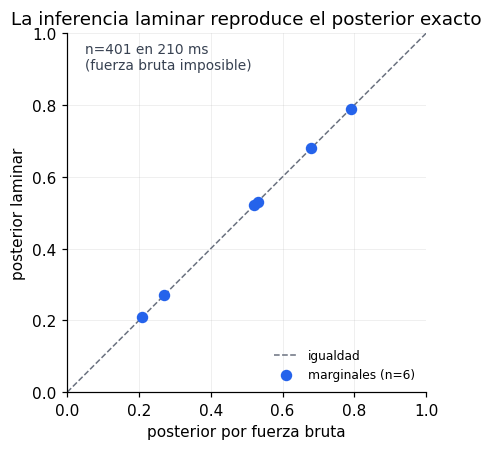

In [12]:
fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.plot([0, 1], [0, 1], color=GRIS, lw=1, ls='--', label='igualdad')
ax.scatter(exact, lam, s=42, color=AZUL, zorder=3, label='marginales (n=6)')
ax.set_xlabel('posterior por fuerza bruta'); ax.set_ylabel('posterior laminar')
ax.set_title('La inferencia laminar reproduce el posterior exacto')
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
ax.annotate(f'n=401 en {dt*1000:.0f} ms\n(fuerza bruta imposible)',
            xy=(0.05, 0.9), fontsize=9, color=TINTA)
ax.legend(frameon=False, fontsize=8, loc='lower right')
plt.tight_layout(); plt.show()

La descomposición por anillos reproduce el posterior exacto —error
numérico esencialmente cero contra fuerza bruta— y termina en milisegundos a
$n=401$. Quedan pendientes la factorización en árboles laminares con varios
hijos, el costo $O(m^2)$ por anillo y la optimización dinámica de la política;
sólo después conviene explorar hipótesis de treewidth acotado.

## 3. El hueco del greedy: acoplar por cobrar hoy

El greedy miope cobra la utilidad que puede limpiar ahora: si dos sujetos
valen mucho, juntarlos en un pool paga $\Pr(\text{ambos sanos})\cdot
(u_1+u_2)$ de un golpe. Pero limpiar a los dos juntos es menos probable que
limpiar a cada uno por separado, y con presupuesto para dos pruebas el óptimo
los prueba individualmente. La instancia de abajo (n=4, B=2, G=2) exhibe el
hueco: el greedy abre acoplando a los dos sujetos de mayor utilidad y el
óptimo por DP los separa.

In [13]:
# instancia testigo (hallada por barrido determinista Random(0), fijada aquí)
p = [0.47, 0.46, 0.53, 0.60]
u = [2.9, 2.8, 1.4, 1.2]      # sujetos 0 y 1 son los de alta utilidad
B, G, n = 2, 2, 4

pool_greedy = _myopic_best_pool(p, u, G, n, 0)     # pool de apertura del greedy
idx_greedy = indices_from_mask(pool_greedy, n)
U_greedy = greedy_myopic_expected_utility(p, u, B, G)
U_opt = solve_optimal_dapts(p, u, B, G, cap=None)[0]
q0, q1 = 1 - p[0], 1 - p[1]
individual = q0 * u[0] + q1 * u[1]

assert set(idx_greedy) == {0, 1}, 'el greedy debe acoplar los dos de alta utilidad'
assert U_opt > U_greedy + 1e-6, 'el óptimo debe superar estrictamente al greedy'
assert abs(U_opt - individual) < 1e-12, 'el valor óptimo debe coincidir con dos consultas individuales'
print(f'greedy abre con el pool {idx_greedy} (acopla a los dos de alta utilidad)')
print(f'  U_greedy = {U_greedy:.4f}')
print(f'  U_óptimo = {U_opt:.4f}   (prueba individual, separando 0 y 1)')
print(f'  hueco    = {U_opt - U_greedy:.4f}  ({100*(U_opt/U_greedy-1):.1f}% sobre el greedy)')

greedy abre con el pool [0, 1] (acopla a los dos de alta utilidad)
  U_greedy = 2.6726
  U_óptimo = 3.0490   (prueba individual, separando 0 y 1)
  hueco    = 0.3764  (14.1% sobre el greedy)


In [14]:
# desglose de las dos jugadas de apertura sobre los sujetos 0 y 1
acoplado = q0 * q1 * (u[0] + u[1])          # un pool {0,1}
print(f'pool acoplado {{0,1}}: Pr(ambos sanos)·(u0+u1) = {q0*q1:.3f}·{u[0]+u[1]:.1f} = {acoplado:.3f}')
print(f'pruebas individuales: q0·u0 + q1·u1            = {individual:.3f}')
print(f'lo miope prefiere acoplar; con B=2 el óptimo separa y gana {individual-acoplado:+.3f}')

pool acoplado {0,1}: Pr(ambos sanos)·(u0+u1) = 0.286·5.7 = 1.631
pruebas individuales: q0·u0 + q1·u1            = 3.049
lo miope prefiere acoplar; con B=2 el óptimo separa y gana +1.418


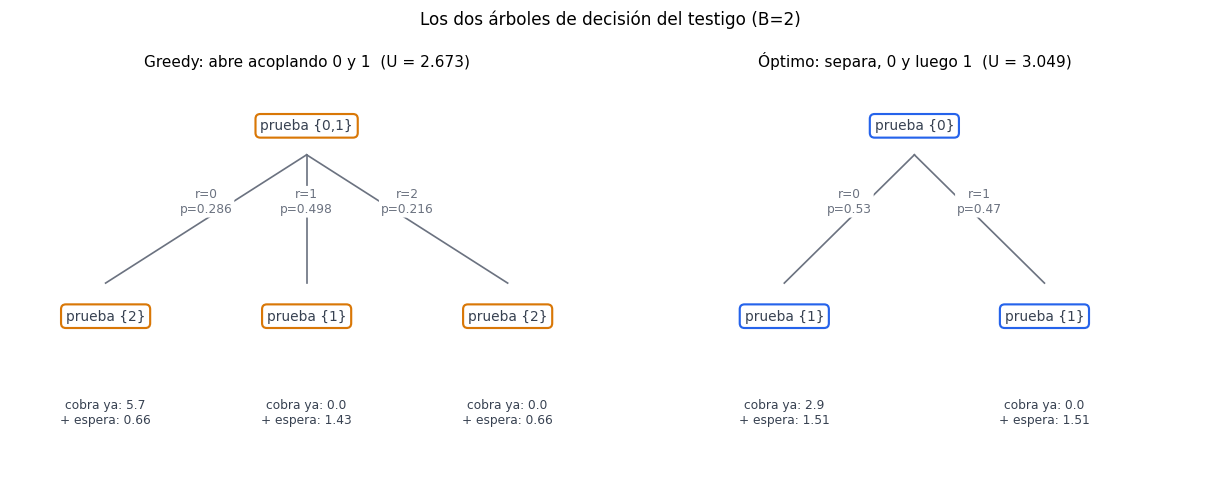

In [15]:
# los dos árboles de decisión, regenerados desde la maquinaria real
from augmented.bayesian import bayesian_update_single_test, _poisson_binomial_pmf

def rama_greedy(r):
    '''Tras observar r en el pool {0,1}: segundo pool miope y su cobro esperado.'''
    post = bayesian_update_single_test(p, pool_greedy, r, n)
    cleared = pool_greedy if r == 0 else 0
    t2 = _myopic_best_pool(post, u, G, n, cleared)
    idx2 = indices_from_mask(t2, n)
    prob_limpio = math.prod(1 - post[i] for i in idx2)
    return idx2, prob_limpio * sum(u[i] for i in idx2)

pmf1 = _poisson_binomial_pmf([p[0], p[1]])
ramas, total_arbol = [], 0.0
for r in range(3):
    idx2, gana2 = rama_greedy(r)
    ahora = (u[0] + u[1]) if r == 0 else 0.0
    ramas.append((r, pmf1[r], idx2, ahora, gana2))
    total_arbol += pmf1[r] * (ahora + gana2)
assert abs(total_arbol - U_greedy) < 1e-9, 'el árbol debe reproducir U_greedy'
assert abs(q0 * u[0] + q1 * u[1] - U_opt) < 1e-12, 'el árbol óptimo debe reproducir U_opt'

def caja(ax, x, y, texto, ec):
    ax.annotate(texto, (x, y), ha='center', va='center', fontsize=9, color=TINTA,
                bbox=dict(boxstyle='round,pad=0.35', fc='white', ec=ec, lw=1.4))

def arista(ax, x0, y0, x1, y1, etiqueta):
    ax.plot([x0, x1], [y0 - 0.07, y1 + 0.08], color=GRIS, lw=1.1, zorder=0)
    ax.annotate(etiqueta, ((x0 + x1) / 2, (y0 + y1) / 2 + 0.02), ha='center',
                fontsize=8, color=GRIS,
                bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none'))

fig, (axg, axo) = plt.subplots(1, 2, figsize=(11.2, 4.6))
for ax in (axg, axo):
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')

# panel greedy: raíz {0,1}, tres ramas por conteo
caja(axg, 0.5, 0.88, 'prueba {0,1}', AMBAR)
for (r, pr, idx2, ahora, gana2), x in zip(ramas, (0.16, 0.5, 0.84)):
    caja(axg, x, 0.42, 'prueba {' + ','.join(map(str, idx2)) + '}', AMBAR)
    arista(axg, 0.5, 0.88, x, 0.42, f'r={r}\np={pr:.3f}')
    axg.annotate(f'cobra ya: {ahora:.1f}\n+ espera: {gana2:.2f}', (x, 0.16),
                 ha='center', fontsize=8, color=TINTA)
axg.set_title(f'Greedy: abre acoplando 0 y 1  (U = {U_greedy:.3f})', fontsize=10)

# panel óptimo: raíz {0}, dos ramas, siempre sigue {1}
caja(axo, 0.5, 0.88, 'prueba {0}', AZUL)
for r, pr, ahora, x in ((0, q0, u[0], 0.28), (1, p[0], 0.0, 0.72)):
    caja(axo, x, 0.42, 'prueba {1}', AZUL)
    arista(axo, 0.5, 0.88, x, 0.42, f'r={r}\np={pr:.2f}')
    axo.annotate(f'cobra ya: {ahora:.1f}\n+ espera: {q1 * u[1]:.2f}', (x, 0.16),
                 ha='center', fontsize=8, color=TINTA)
axo.set_title(f'Óptimo: separa, 0 y luego 1  (U = {U_opt:.3f})', fontsize=10)
fig.suptitle('Los dos árboles de decisión del testigo (B=2)', fontsize=11)
plt.tight_layout(); plt.show()

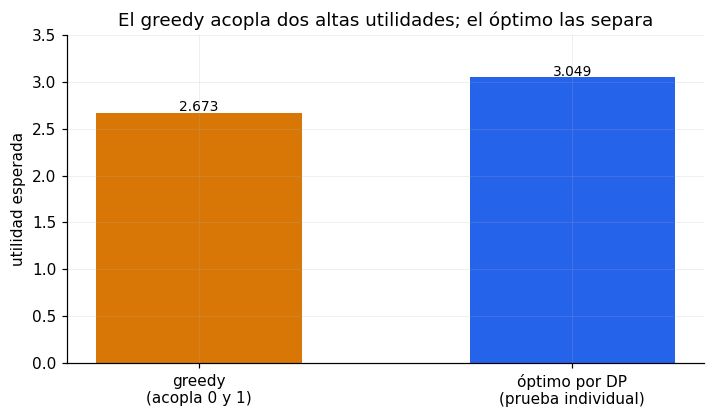

In [16]:
fig, ax = plt.subplots(figsize=(6.6, 3.9))
labels = ['greedy\n(acopla 0 y 1)', 'óptimo por DP\n(prueba individual)']
vals = [U_greedy, U_opt]
bars = ax.bar(labels, vals, color=[AMBAR, AZUL], width=0.55)
ax.set_ylabel('utilidad esperada')
ax.set_title('El greedy acopla dos altas utilidades; el óptimo las separa')
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)
ax.set_ylim(0, U_opt * 1.15)
plt.tight_layout(); plt.show()

El greedy paga la tentación de cobrar hoy: acopla a los dos sujetos
valiosos para llevarse $u_0+u_1$ en una sola limpieza, un evento raro; el
óptimo los separa en dos apuestas independientes y gana ~14% con $B=2$. No
está demostrado que el testigo sea mínimo ni si existe una familia donde el
acoplamiento pierda una fracción constante al crecer $n$ y el presupuesto.

## 4. Caminos alternantes en Gibbs: cruzar niveles de conteo

Tres personas con prior 0.15, una prueba sobre $\{0,1\}$ con un activo y otra
sobre $\{1,2\}$ con un activo, dejan dos mundos: la persona 1 infectada
(total 1) o las personas 0 y 2 infectadas (total 2). Un swap —apagar uno,
prender otro— conserva el total y no puede pasar de un mundo al otro; hace
falta un movimiento que cambie el total respetando cada prueba, el camino
alternante. El posterior exacto del ejemplo es $[0.15, 0.85, 0.15]$: el
muestreador restringido a swaps es no ergódico entre niveles y sesga el
posterior, mientras que, con las semillas fijadas, los caminos alternantes
cruzan ambos niveles y aproximan la referencia. En cadenas impares de
$n=17,19$ el swap queda clavado con error 0.85. Nada de esto demuestra
irreducibilidad para fibras generales.

In [17]:
# el ejemplo de tres personas: el posterior exacto y el argumento del atrapamiento
p3 = [0.15, 0.15, 0.15]
hist3 = ((mask_from_indices([0, 1]), 1), (mask_from_indices([1, 2]), 1))
exact3 = bayesian_update_by_counting(p3, hist3, 3)
print('mundos válidos: (0,1,0) total=1   y   (1,0,1) total=2')
print('posterior exacto  P(Z_i=1):', [round(v, 3) for v in exact3])
print('un swap conserva el total -> no puede cruzar de total 1 a total 2')

mundos válidos: (0,1,0) total=1   y   (1,0,1) total=2
posterior exacto  P(Z_i=1): [0.15, 0.85, 0.15]
un swap conserva el total -> no puede cruzar de total 1 a total 2


In [18]:
# instancias grandes: cadena impar, un solo componente por encima del umbral
# (EXACT_ACTIVE_THRESHOLD=16), lo que fuerza el camino MCMC de verdad.
def cadena_impar(n):
    p = [0.15] * n
    hist = tuple((mask_from_indices([i, i + 1]), 1) for i in range(n - 1))
    return p, hist

casos = [('n=17', 17, 2), ('n=19', 19, 1)]   # (etiqueta, n, semilla)
filas = []
for etq, n, seed in casos:
    p, hist = cadena_impar(n)
    exact = bayesian_update_by_counting(p, hist, n)
    st_alt, st_swap = [], []
    alt = gibbs_update(p, hist, n, num_iterations=20000, burn_in=2000, seed=seed,
                       count_preserving_only=False, mcmc_stats=st_alt)
    swap = gibbs_update(p, hist, n, num_iterations=20000, burn_in=2000, seed=seed,
                        count_preserving_only=True, mcmc_stats=st_swap)
    err_alt = max(abs(alt[i] - exact[i]) for i in range(n))
    err_swap = max(abs(swap[i] - exact[i]) for i in range(n))
    niv_alt = sorted((st_alt[0]['count_hist'] if st_alt else {}).keys())
    niv_swap = sorted((st_swap[0]['count_hist'] if st_swap else {}).keys())
    assert err_alt < 0.05, f'{etq}: el alternante debería converger (err={err_alt})'
    assert err_swap > 5 * err_alt, f'{etq}: el swap debería sesgar mucho más'
    filas.append((etq, err_alt, err_swap, niv_alt, niv_swap, st_alt[0], st_swap[0]))
    print(f'{etq}: err_alt={err_alt:.4f}  err_swap={err_swap:.4f}  '
          f'niveles_alt={niv_alt}  niveles_swap={niv_swap}')

n=17: err_alt=0.0109  err_swap=0.8500  niveles_alt=[8, 9]  niveles_swap=[9]


n=19: err_alt=0.0024  err_swap=0.8500  niveles_alt=[9, 10]  niveles_swap=[10]


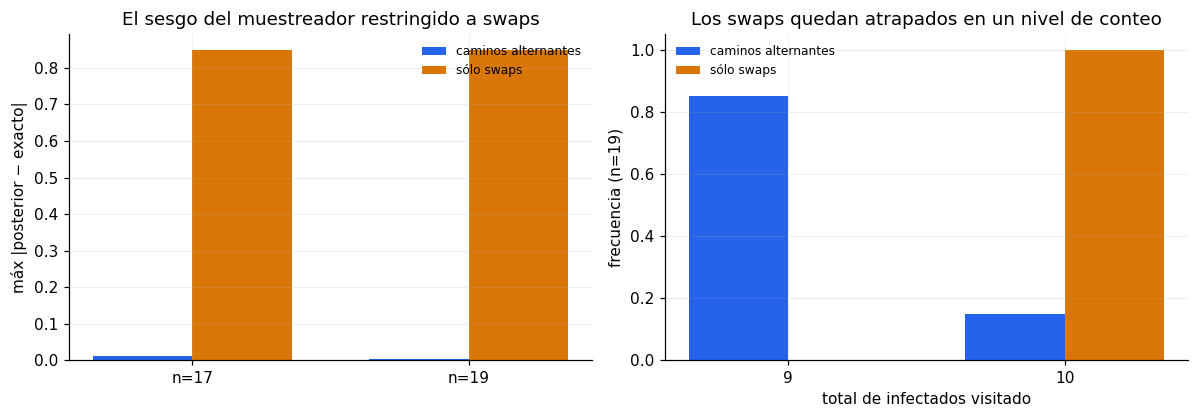

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.9))

# izquierda: error del posterior por kernel
etqs = [f[0] for f in filas]
x = np.arange(len(etqs)); w = 0.36
ax1.bar(x - w/2, [f[1] for f in filas], w, color=AZUL, label='caminos alternantes')
ax1.bar(x + w/2, [f[2] for f in filas], w, color=AMBAR, label='sólo swaps')
ax1.set_xticks(x); ax1.set_xticklabels(etqs)
ax1.set_ylabel('máx |posterior − exacto|')
ax1.set_title('El sesgo del muestreador restringido a swaps')
ax1.legend(frameon=False, fontsize=8)

# derecha: niveles de conteo visitados (n=19), el swap se queda en uno
f = filas[-1]
ha, hs = f[5]['count_hist'], f[6]['count_hist']
niveles = sorted(set(ha) | set(hs))
xa = np.arange(len(niveles))
tot_a = sum(ha.values()); tot_s = sum(hs.values())
ax2.bar(xa - w/2, [ha.get(k, 0)/tot_a for k in niveles], w, color=AZUL,
        label='caminos alternantes')
ax2.bar(xa + w/2, [hs.get(k, 0)/tot_s for k in niveles], w, color=AMBAR,
        label='sólo swaps')
ax2.set_xticks(xa); ax2.set_xticklabels(niveles)
ax2.set_xlabel('total de infectados visitado'); ax2.set_ylabel('frecuencia (n=19)')
ax2.set_title('Los swaps quedan atrapados en un nivel de conteo')
ax2.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

El swap nunca ve el otro nivel —posterior sesgado hasta 0.85, histograma
clavado en un solo total— y el alternante cruza y aproxima la proporción
exacta. El código incorpora un factor de Hastings de espejo para la asimetría
de la propuesta, pero falta justificar ese cociente y la irreducibilidad:
mientras no se sepa si el generador conecta toda fibra de conteos o hay
componentes inalcanzables, el resultado es empírico, no un teorema de
convergencia.

## 5. Cota superior: información perfecta con penalización

Para acotar por arriba al óptimo se le da al planificador un superpoder:
conocer de antemano el estatus de algunas personas. El clarividente puro
($U_{PI}$) acota, pero flojo. La relajación con penalización (Brown–Smith–Sun)
le cobra el superpoder: cada estatus revelado tiene un precio $\pi_t$ de media
cero bajo la filtración natural, así que $\text{OPT}\le U_{pen}(c)$ para
cualquier potencial y cualquier escala dual $c$. Como no se conoce de antemano
la escala que más aprieta, se reporta
$U_{pen}=\min\{U_{PI},U_{pen}(0.5),U_{pen}(1),U_{pen}(2)\}$ — el mínimo de
cotas válidas es válido, e incluir la escala 0 garantiza
$\text{OPT}\le U_{pen}\le U_{PI}$ por construcción. La implementación exacta
enumera perfiles e historias: es un prototipo para $n$ pequeño, no una cota
escalable.

In [20]:
p = [0.40, 0.55, 0.30, 0.50]; u = [1.0, 2.0, 3.0, 1.5]; G = 2
Bs = [1, 2, 3, 4]
opt_v, pen_v, pi_v = [], [], []
for B in Bs:
    opt = solve_optimal_dapts(p, u, B, G, cap=None)[0]
    pi = u_pi_exact(p, u, B, G)
    # Incluir escala 0 hace que el mínimo contenga explícitamente U_PI.
    pen = u_pen_exact(p, u, B, G, scales=(0.0, 0.5, 1.0, 2.0))
    assert opt <= pen + 1e-6, f'U_pen debe acotar a OPT (B={B})'
    assert pen <= pi + 1e-6, f'U_pen debe ser <= U_PI por construcción (B={B})'
    opt_v.append(opt); pen_v.append(pen); pi_v.append(pi)
print('B   OPT(DP)   U_pen    U_PI')
for B, o, pn, pi in zip(Bs, opt_v, pen_v, pi_v):
    print(f'{B}  {o:>7.3f} {pn:>8.3f} {pi:>7.3f}')

B   OPT(DP)   U_pen    U_PI
1    2.100    2.813   3.769
2    3.090    4.050   4.350
3    4.042    4.350   4.350
4    4.350    4.350   4.350


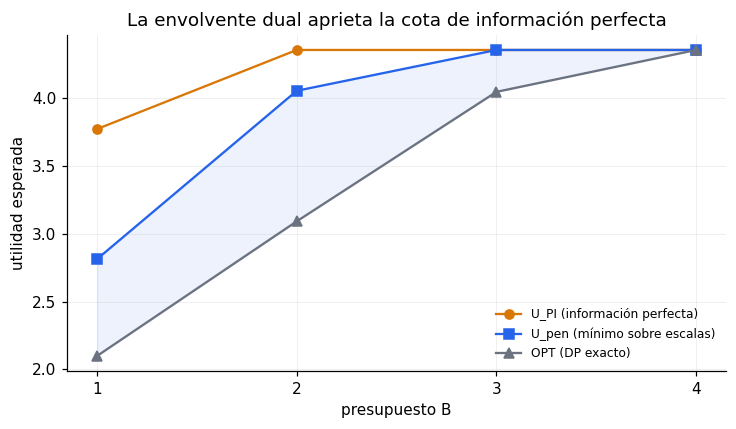

In [21]:
fig, ax = plt.subplots(figsize=(6.8, 4.0))
ax.plot(Bs, pi_v, 'o-', color=AMBAR, label='U_PI (información perfecta)')
ax.plot(Bs, pen_v, 's-', color=AZUL, label='U_pen (mínimo sobre escalas)')
ax.plot(Bs, opt_v, '^-', color=GRIS, label='OPT (DP exacto)')
ax.fill_between(Bs, opt_v, pen_v, color=AZUL, alpha=0.08)
ax.set_xlabel('presupuesto B'); ax.set_ylabel('utilidad esperada')
ax.set_title('La envolvente dual aprieta la cota de información perfecta')
ax.set_xticks(Bs); ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

$U_{pen}$ queda entre el óptimo y la cota clarividente, con mejora
visible sobre $U_{PI}$ a presupuesto chico; al crecer $B$ las tres convergen a
$U_{\max}$ porque la instancia se satura. Los siguientes pasos son elegir el
potencial $\hat V$ de la penalización (nulo, $U_{\max}$, greedy) y diseñar una
aproximación escalable con garantías: la versión exacta enumera $2^n$ perfiles
y un espacio exponencial de historias.

## 6. Más allá de β: reducción de entropía del posterior

El parámetro $\beta$ premia las pruebas que informan sobre personas sanas, un
criterio pobre. Una alternativa es premiar la reducción de entropía del
posterior: pruebas que, por la combinatoria, no devuelven "todos sanos" ni
"todos infectados" pero bajan la incertidumbre de golpe, al estilo de los
árboles de decisión. En la instancia de abajo, barrer $\beta$ con la métrica
de entropía no cambia la política ni la utilidad y no alcanza al óptimo; la
utilidad se evalúa exactamente enumerando los 16 perfiles latentes, así que la
comparación no depende de la aproximación por marginales. Una instancia no
basta para descartar el criterio en general.

In [22]:
p = [0.35, 0.55, 0.45, 0.60]; u = [3.0, 1.0, 2.5, 1.5]; B, G = 2, 2
U_opt = solve_optimal_dapts(p, u, B, G, cap=None)[0]
betas = [0.0, 0.25, 0.5, 1.0, 2.0, 4.0]

def eu_beta_exacta(beta):
    total = 0.0
    for z in range(1 << len(p)):
        peso = 1.0
        for i, pi in enumerate(p):
            peso *= pi if (z >> i) & 1 else (1 - pi)
        total += peso * greedy_myopic_beta_simulate(
            p, u, B, G, z, beta, info_metric='entropy')[2]
    return total

U_ent = [eu_beta_exacta(b) for b in betas]
U_plano = U_ent[0]
for b, v in zip(betas, U_ent):
    assert v <= U_opt + 1e-9, f'ningún beta puede superar el óptimo (beta={b})'
    aprox = greedy_myopic_beta_expected_utility(p, u, B, G, b, info_metric='entropy')
    assert abs(v - aprox) < 1e-12, f'la recursión y la evaluación exacta difieren (beta={b})'
mejora = max(U_ent) - U_plano
print(f'óptimo por DP        : {U_opt:.4f}')
print(f'greedy plano (β=0)   : {U_plano:.4f}')
print(f'mejor β con entropía : {max(U_ent):.4f}   (gana {mejora:+.4f} sobre el plano)')
print(f'hueco que queda al óptimo: {U_opt - max(U_ent):.4f}')

óptimo por DP        : 3.3250
greedy plano (β=0)   : 3.1528
mejor β con entropía : 3.1528   (gana +0.0000 sobre el plano)
hueco que queda al óptimo: 0.1722


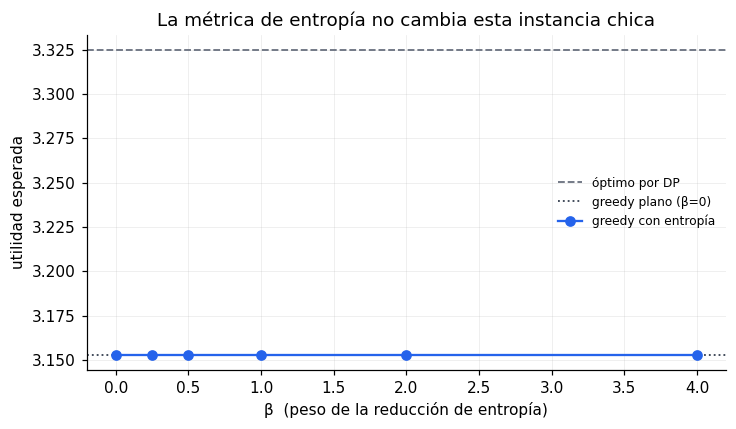

In [23]:
fig, ax = plt.subplots(figsize=(6.8, 4.0))
ax.axhline(U_opt, color=GRIS, ls='--', lw=1.2, label='óptimo por DP')
ax.axhline(U_plano, color=TINTA, ls=':', lw=1.2, label='greedy plano (β=0)')
ax.plot(betas, U_ent, 'o-', color=AZUL, label='greedy con entropía')
ax.set_xlabel('β  (peso de la reducción de entropía)')
ax.set_ylabel('utilidad esperada')
ax.set_title('La métrica de entropía no cambia esta instancia chica')
ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

La entropía deja exactamente la misma utilidad y no cierra el hueco al
óptimo: un resultado negativo puntual. Antes de descartarla harían falta un
barrido de instancias pequeñas con verdad de referencia y una evaluación
grande con réplicas suficientes; la implementación grande actual no da para
una conclusión.

### 6b. Dos alternativas: dispersión unilateral y potencial $\hat V=U_{PI}$

La entropía tiene dos defectos: ignora las utilidades $u_i$ y premia certeza
en ambas direcciones, cuando sólo el extremo sano paga. La dispersión
unilateral corrige ambos: premia $E\big[\sum_i u_i\,(p_i-p_i')_+\big]$, el
movimiento del posterior hacia el extremo cobrable, pesado por valor. La otra
alternativa cambia de moneda: elegir el pool que maximiza recompensa inmediata
más $E[U_{PI}(\text{posterior})]$, la cota de la sección 5 usada como
potencial. En la misma instancia, la dispersión deja la política idéntica al
greedy plano para todo $\beta$, igual que la entropía; el potencial
$\hat V=U_{PI}$ alcanza el óptimo por DP a precisión de máquina y abre con la
prueba individual del sujeto de mayor valor en vez del pool acoplado. Es una
instancia, no un teorema.

In [24]:
# las dos métricas, evaluadas exactamente sobre los 16 perfiles latentes
from augmented.core import all_pools_from_mask, compute_active_mask, test_result
from augmented.bayesian import bayesian_update_single_test, _poisson_binomial_pmf

def dispersion_unilateral(pool, cur_p, n, u):
    '''E_r[ sum_i u_i * max(p_i - p_i', 0) ]: movimiento hacia el extremo sano.'''
    idx = indices_from_mask(pool, n)
    pmf = _poisson_binomial_pmf([cur_p[i] for i in idx])
    gain = 0.0
    for r in range(len(idx) + 1):
        if pmf[r] < 1e-15:
            continue
        post = bayesian_update_single_test(cur_p, pool, r, n)
        gain += pmf[r] * sum(u[i] * max(cur_p[i] - post[i], 0.0) for i in range(n))
    return gain

def pool_dispersion(cur_p, u, G, n, cleared, beta):
    active, _ = compute_active_mask(cur_p, cleared, n)
    best_pool, best = 0, 0.0
    for pool in (all_pools_from_mask(active, G, include_empty=False) if active else []):
        idx = indices_from_mask(pool, n)
        prob_clear = math.prod(1.0 - cur_p[i] for i in idx)
        gain = sum(u[i] for i in idx if not (cleared >> i & 1))
        score = prob_clear * gain + beta * dispersion_unilateral(pool, cur_p, n, u)
        if score > best:
            best, best_pool = score, pool
    return best_pool

def pool_potencial(cur_p, u, G, n, cleared, b_rest):
    '''Lookahead de un paso: inmediato + U_PI del estado posterior (prototipo 2^n).'''
    active, _ = compute_active_mask(cur_p, cleared, n)
    best_pool, best = 0, 0.0
    for pool in (all_pools_from_mask(active, G, include_empty=False) if active else []):
        idx = indices_from_mask(pool, n)
        pmf = _poisson_binomial_pmf([cur_p[i] for i in idx])
        gain = sum(u[i] for i in idx if not (cleared >> i & 1))
        score = 0.0
        for r in range(len(idx) + 1):
            if pmf[r] < 1e-15:
                continue
            post = bayesian_update_single_test(cur_p, pool, r, n)
            new_cleared = cleared | pool if r == 0 else cleared
            u_rest = [0.0 if (new_cleared >> i & 1) else u[i] for i in range(n)]
            futuro = u_pi_exact(post, u_rest, b_rest, G) if b_rest > 0 else 0.0
            score += pmf[r] * ((gain if r == 0 else 0.0) + futuro)
        if score > best:
            best, best_pool = score, pool
    return best_pool

def eu_politica_exacta(elige_pool):
    '''elige_pool(cur_p, cleared, t) -> pool; evalúa enumerando los 2^n perfiles.'''
    n = len(p); total = 0.0
    for z in range(1 << n):
        peso = math.prod(pi if (z >> i) & 1 else (1 - pi) for i, pi in enumerate(p))
        cur_p, cleared = list(p), 0
        for t in range(B):
            pool = elige_pool(cur_p, cleared, t)
            if pool == 0:
                break
            r = test_result(pool, z)
            if r == 0:
                cleared |= pool
            cur_p = bayesian_update_single_test(cur_p, pool, r, n)
        total += peso * sum(u[i] for i in indices_from_mask(cleared, n))
    return total

n6 = len(p)
U_disp = [eu_politica_exacta(lambda cp, cl, t, b=b: pool_dispersion(cp, u, G, n6, cl, b))
          for b in betas]
U_pot = eu_politica_exacta(lambda cp, cl, t: pool_potencial(cp, u, G, n6, cl, B - t - 1))
apertura = indices_from_mask(pool_potencial(list(p), u, G, n6, 0, B - 1), n6)

assert abs(U_disp[0] - U_plano) < 1e-12, 'con beta=0 la dispersión debe ser el greedy plano'
assert all(abs(v - U_plano) < 1e-12 for v in U_disp), 'la dispersión no mueve esta instancia'
assert all(v <= U_opt + 1e-9 for v in U_disp), 'ninguna política puede superar el óptimo'
assert U_pot <= U_opt + 1e-9, 'el potencial tampoco puede superar el óptimo'
assert abs(U_pot - U_opt) < 1e-9, 'en esta instancia el potencial debe alcanzar el óptimo'
print(f'óptimo por DP           : {U_opt:.4f}')
print(f'greedy plano (β=0)      : {U_plano:.4f}')
print(f'mejor β con entropía    : {max(U_ent):.4f}')
print(f'mejor β con dispersión  : {max(U_disp):.4f}')
print(f'potencial V̂=U_PI        : {U_pot:.4f}   (abre con {apertura}, hueco {U_opt-U_pot:.1e})')

óptimo por DP           : 3.3250
greedy plano (β=0)      : 3.1528
mejor β con entropía    : 3.1528
mejor β con dispersión  : 3.1528
potencial V̂=U_PI        : 3.3250   (abre con [0], hueco 4.4e-16)


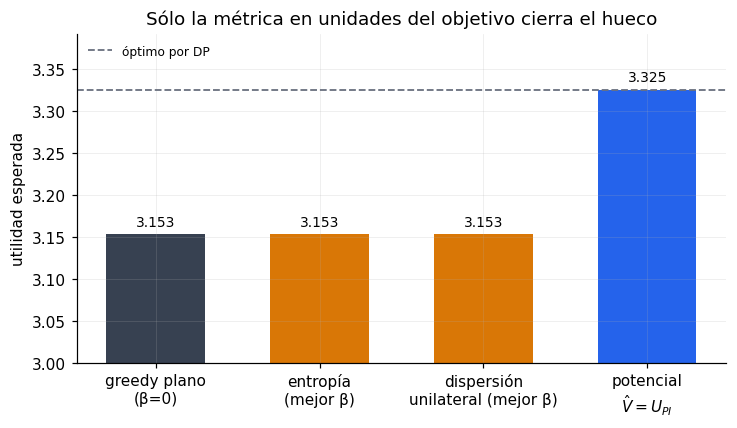

In [25]:
fig, ax = plt.subplots(figsize=(6.8, 4.0))
nombres = ['greedy plano\n(β=0)', 'entropía\n(mejor β)', 'dispersión\nunilateral (mejor β)',
           'potencial\n$\\hat V = U_{PI}$']
vals = [U_plano, max(U_ent), max(U_disp), U_pot]
ax.bar(nombres, vals, color=[TINTA, AMBAR, AMBAR, AZUL], width=0.6)
ax.axhline(U_opt, color=GRIS, ls='--', lw=1.2, label='óptimo por DP')
for xb, v in enumerate(vals):
    ax.text(xb, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
ax.set_ylabel('utilidad esperada')
ax.set_ylim(3.0, U_opt * 1.02)
ax.set_title('Sólo la métrica en unidades del objetivo cierra el hueco')
ax.legend(frameon=False, fontsize=8, loc='upper left')
plt.tight_layout(); plt.show()

Las dos métricas de información genérica dejan la política intacta: el
bono no logra que el greedy renuncie al pool que cobra hoy. El potencial
$\hat V=U_{PI}$ sí, porque valora el estado que cada prueba deja en la misma
unidad que el objetivo, y conecta las secciones 5 y 6: la misma $\hat V$ que
aprieta la cota penalizada sirve como política. Su costo actual es de
prototipo —cada candidato evalúa $U_{PI}$ enumerando $2^n$ perfiles—; escalar
pide una $U_{PI}$ aproximada y barata.

## 7. Rollout vs. greedy miope en las instancias del paper (N=50)

El rollout elige cada prueba preguntando cuánto acabará cobrando en total:
recorre los resultados posibles, actualiza el posterior y supone que el resto
del presupuesto lo juega el miope. En el juguete —A y B con P(sano) = 0.4, C
segura, utilidades 1, dos pruebas binarias— el miope cobra {C} hoy porque
1.0 > 0.8; el rollout monta a A sobre la certeza de C: si {A,C} sale limpia
cobra doble y, si sale positiva, el culpable sólo puede ser A y queda la
segunda prueba para cobrar {C}. Con eso alcanza el óptimo exacto (1.56 vs.
1.40 del miope). En instancias como las del paper (N=50, B=5,
$u_i\in\{1,2,3\}$, priors uniformes, 1000 instancias pareadas por setting), el
rollout mejora al miope en el dinámico binario y el premio se encoge hasta el
cero estadístico en el aumentado con G=5.

In [26]:
# juguete exacto: el rollout alcanza el óptimo que el miope deja ir
from itertools import combinations, product as iproduct

ph7 = [0.4, 0.4, 1.0]                     # P(sano) de A, B, C; u = 1 los tres
pools7 = [frozenset(c) for g in (1, 2, 3) for c in combinations(range(3), g)]

def eu_plan(t1, t2neg, t2pos):
    '''EU exacta de un plan adaptativo de 2 pruebas binarias (8 perfiles).'''
    total = 0.0
    for z in iproduct([0, 1], repeat=3):  # 1 = sano
        peso = math.prod(ph7[i] if z[i] else 1 - ph7[i] for i in range(3))
        conf = set()
        neg1 = all(z[i] for i in t1)
        if neg1:
            conf |= t1
        t2 = t2neg if neg1 else t2pos
        if all(z[i] for i in t2):
            conf |= t2
        total += peso * len(conf)
    return total

# miope: {C} (score 1.0 > 0.8 de {A,C}), luego {A}; rollout: {A,C}, y adapta
U_miope7 = eu_plan(frozenset({2}), frozenset({0}), frozenset({0}))
U_roll7 = eu_plan(frozenset({0, 2}), frozenset({1}), frozenset({2}))
U_opt7 = max(eu_plan(t1, a, b) for t1 in pools7 for a in pools7 for b in pools7)
assert abs(U_miope7 - 1.40) < 1e-12 and abs(U_roll7 - 1.56) < 1e-12
assert abs(U_roll7 - U_opt7) < 1e-12, 'el rollout debe alcanzar el óptimo aquí'
print(f'miope {U_miope7:.2f} < rollout {U_roll7:.2f} = óptimo {U_opt7:.2f}')

miope 1.40 < rollout 1.56 = óptimo 1.56


In [27]:
# N=50: welfare realizado pareado, 4 settings (CSV versionado; se
# regenera con `python augmented/experiments_rollout_n50.py csv`, ~25 min;
# el argmax miope exacto a N=50 usa composiciones por clase de utilidad)
import csv as _csv
from collections import defaultdict

filas = defaultdict(list)
with open(ROOT / 'augmented' / 'data' / 'rollout_n50.csv') as fh:
    for row in _csv.DictReader(fh):
        filas[(row['model'], int(row['G']))].append(
            (float(row['w_myopic']), float(row['w_rollout'])))

orden = [('binary', 5), ('binary', 3), ('counting', 3), ('counting', 5)]
nombres7 = ['dinámico binario\nG=5', 'dinámico binario\nG=3',
            'dinámico aumentado\nG=3', 'dinámico aumentado\nG=5']
pct, ci95 = [], []
for clave in orden:
    datos = np.array(filas[clave])
    assert len(datos) == 1000, f'faltan instancias en {clave}'
    wm, d = datos[:, 0], datos[:, 1] - datos[:, 0]
    se = d.std(ddof=1) / np.sqrt(len(d))
    assert 19 < wm.mean() < 23, 'ancla: el miope del paper ronda 21'
    pct.append(100 * d.mean() / wm.mean())
    ci95.append(100 * 1.96 * se / wm.mean())
    print(f'{clave[0]:9s} G={clave[1]}: miope {wm.mean():6.3f}  '
          f'diff {d.mean():+.4f} ± {1.96 * se:.4f} (IC 95%)  '
          f'[{pct[-1]:+.2f}%]')
# el binario gana con significancia; el aumentado G=5 es cero estadístico
assert pct[0] - ci95[0] > 0 and pct[1] - ci95[1] > 0
assert abs(pct[3]) < ci95[3]

binary    G=5: miope 20.592  diff +0.3310 ± 0.2881 (IC 95%)  [+1.61%]
binary    G=3: miope 20.354  diff +0.2970 ± 0.2027 (IC 95%)  [+1.46%]
counting  G=3: miope 20.789  diff +0.2300 ± 0.2333 (IC 95%)  [+1.11%]
counting  G=5: miope 21.261  diff -0.0720 ± 0.3522 (IC 95%)  [-0.34%]


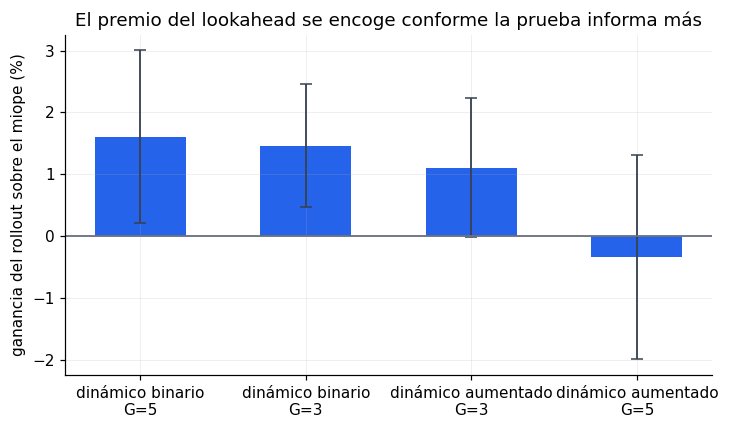

In [28]:
fig, ax = plt.subplots(figsize=(6.8, 4.0))
xs = np.arange(len(orden))
ax.bar(xs, pct, yerr=ci95, capsize=4, color=AZUL, width=0.55,
       error_kw={'ecolor': TINTA, 'lw': 1.2})
ax.axhline(0, color=GRIS, lw=1.2)
ax.set_xticks(xs, nombres7)
ax.set_ylabel('ganancia del rollout sobre el miope (%)')
ax.set_title('El premio del lookahead se encoge conforme la prueba informa más')
plt.tight_layout(); plt.show()

El premio del lookahead decrece con la información por prueba: es real
en el dinámico binario y desaparece en el aumentado con G=5, donde cada conteo
revela tanto que al miope casi no le queda nada por perder. Ahí el rollout
predice ganar según su propio modelo de marginales y no se materializa: la
garantía rollout ≥ miope supone esperanzas exactas, y el error de la
aproximación de independencia supera el premio. Visto al revés, con conteo el
greedy trivial ya es casi óptimo: la prueba rica no sólo gana utilidad,
simplifica el algoritmo. La ganancia binaria (~1.5%) es del orden del hallazgo
central del paper (+1.2% a +2.8% de dinámico sobre estático), lo que sugiere
presentar el rollout como resultado para ese mundo y formalizar su espejo.